# CO₂ + H₂O: viscosity and density versus pressure and temperature

**Objective.** Collect all eligible systems containing both CO₂ and H₂O for
viscosity and density, rank publications using the complete matching result,
retain the top ten, plot every selected property, and export one CSV per query
with full publication and experimental metadata.

**Success criteria.** Fetch upstream configuration from `thermoml-io`; require
both components simultaneously while allowing higher-order systems; select
pressure/temperature only when reported as independent variables; and apply
the publication limit after the complete matching scan.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

from thermoml_io import (
    catalog_thermoml_archive,
    fetch_thermoml_archive,
    get_archive_source,
    query_thermoml_archive,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LOCAL_CACHE = PROJECT_ROOT / "notebooks/local-only/archive"
LOCAL_EXPORT = PROJECT_ROOT / "notebooks/local-only/exports"
CO2_INCHIKEY = "CURLTUGMZLYLDI-UHFFFAOYSA-N"
H2O_INCHIKEY = "XLYOFNOQVPJJNP-UHFFFAOYSA-N"
PUBLICATION_LIMIT = 10

source = get_archive_source()
archive_path = fetch_thermoml_archive(cache_dir=LOCAL_CACHE)
display(
    pd.DataFrame(
        {
            "field": ["snapshot", "snapshot date", "NIST record", "SHA-256"],
            "value": [
                source.filename,
                source.snapshot_date,
                source.record_version,
                source.sha256,
            ],
        }
    )
)

,field,value
0,snapshot,ThermoML.v2020-09-30.tgz
1,snapshot date,2020-09-30
2,NIST record,1.2.6
3,SHA-256,231161b5e443dc1ae0e5da8429d86a88474cb722016e5b...


## Complete-snapshot catalog

This scan lists the exact property and independent-variable vocabulary present
in the pinned database. It makes the category/subcategory interface
inspectable rather than encoding a second hand-written property database.

In [2]:
catalog = catalog_thermoml_archive(archive_path)

transport_properties = pd.DataFrame(
    [
        {"property": item.label, "relationship count": item.count}
        for item in catalog.properties("transport")
    ]
)
volumetric_properties = pd.DataFrame(
    [
        {"property": item.label, "relationship count": item.count}
        for item in catalog.properties("volumetric")
    ]
)
available_conditions = pd.DataFrame(
    [
        {
            "category": category,
            "property query": property_query,
            "condition": item.label,
            "relationship count": item.count,
        }
        for category, property_query in (
            ("transport", "viscosity"),
            ("volumetric", "density"),
        )
        for item in catalog.independent_variables(category, property_query)
    ]
)

display(
    pd.DataFrame(
        {
            "metric": [
                "XML members",
                "decoded members",
                "catalog combinations",
                "official JSON recoveries",
                "explicit failures",
            ],
            "count": [
                catalog.xml_document_count,
                catalog.parsed_document_count,
                len(catalog.entries),
                len(catalog.recoveries),
                len(catalog.failures),
            ],
        }
    )
)
display(transport_properties)
display(volumetric_properties)
display(available_conditions.head(20))

,metric,count
0,XML members,11923
1,decoded members,11923
2,catalog combinations,696
3,official JSON recoveries,2
4,explicit failures,0


,property,relationship count
0,"Viscosity, Pa*s",570728
1,"Electrical conductivity, S/m",155966
2,"Thermal conductivity, W/m/K",51382
3,"Molar conductivity, S*m2/mol",29491
4,"Kinematic viscosity, m2/s",13916
5,"Binary diffusion coefficient, m2/s",12407
6,"Thermal diffusivity, m2/s",7033
7,"Tracer diffusion coefficient, m2/s",681
8,"Self diffusion coefficient, m2/s",499


,property,relationship count
0,"Mass density, kg/m3",1892688
1,"Excess molar volume, m3/mol",32181
2,"Isobaric coefficient of expansion, 1/K",9651
3,"Apparent molar volume, m3/mol",9641
4,"Specific volume, m3/kg",9163
5,"Molar volume, m3/mol",8448
6,"Amount density, mol/m3",7954
7,"Isothermal compressibility, 1/kPa",3484
8,Compressibility factor,1848
9,"Partial molar volume, m3/mol",1002


,category,property query,condition,relationship count
0,transport,viscosity,"Temperature, K",254847
1,transport,viscosity,Mole fraction,141318
2,transport,viscosity,"Molality, mol/kg",76687
3,transport,viscosity,"Solvent: Molality, mol/kg",37696
4,transport,viscosity,"Pressure, kPa",33030
5,transport,viscosity,Mass fraction,17033
6,transport,viscosity,Solvent: Mass fraction,8827
7,transport,viscosity,"Amount concentration (molarity), mol/dm3",8234
8,transport,viscosity,Solvent: Mole fraction,3659
9,transport,viscosity,"Solvent: Amount concentration (molarity), mol/dm3",663


## Component policy

Here `contains` means **CO₂ and H₂O must both occur** in every dataset; binary,
ternary, and higher-order systems remain eligible. For an exact binary system,
change the mode to `exact`. For a controlled component pool, use `within` and
supply the resolved identities as `required_components`. The familiar names
below are resolved once against the component index gathered by the catalog;
each property query reuses those stable identities.

In [3]:
component_index = catalog.component_index
co2 = component_index.resolve("carbon dioxide")
water = component_index.resolve("water")
display(
    pd.DataFrame(
        [
            {
                "query": query,
                "preferred name": identity.preferred_name,
                "formula": " | ".join(identity.formulas),
                "InChIKey": " | ".join(identity.standard_inchi_keys),
            }
            for query, identity in (("carbon dioxide", co2), ("water", water))
        ]
    )
)

query_specs = {
    "viscosity_vs_pressure": ("transport", "viscosity", "pressure"),
    "viscosity_vs_temperature": ("transport", "viscosity", "temperature"),
    "density_vs_pressure": ("volumetric", "density", "pressure"),
    "density_vs_temperature": ("volumetric", "density", "temperature"),
}

required_system = (co2, water)
results = {
    label: query_thermoml_archive(
        archive_path,
        components=required_system,
        component_index=component_index,
        component_match="contains",
        data_category=category,
        property_name=property_query,
        independent_variable=condition,
        publication_limit=PUBLICATION_LIMIT,
        serialized_prefilters=(CO2_INCHIKEY, H2O_INCHIKEY),
    )
    for label, (category, property_query, condition) in query_specs.items()
}

summary = pd.DataFrame(
    [
        {
            "query": label,
            "available publications": result.available_publication_count,
            "selected publications": len(result.publications),
            "matching datasets before publication limit": result.matched_dataset_count,
            "returned relationships": len(result.table.rows),
            "official JSON recoveries after prefilter": len(result.recoveries),
            "parse failures after prefilter": len(result.failures),
        }
        for label, result in results.items()
    ]
)
display(summary)

,query,preferred name,formula,InChIKey
0,carbon dioxide,carbon dioxide,CO2,CURLTUGMZLYLDI-UHFFFAOYSA-N
1,water,water,H2O,XLYOFNOQVPJJNP-UHFFFAOYSA-N


,query,available publications,selected publications,matching datasets before publication limit,returned relationships,official JSON recoveries after prefilter,parse failures after prefilter
0,viscosity_vs_pressure,6,6,8,299,0,0
1,viscosity_vs_temperature,19,10,29,1409,0,0
2,density_vs_pressure,11,10,21,2314,0,0
3,density_vs_temperature,31,10,52,3704,0,0


## Top publications and retained metadata

Publication ranking uses only rows matching the requested property and x-axis.
The data table repeats the complete citation and experimental context for each
returned value.

In [4]:
publication_rankings = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "query": label,
                    "rank": rank,
                    "authors and year": item.authors_year,
                    "doi": item.doi,
                    "year": item.year,
                    "relationships": item.relationship_count,
                    "title": item.title,
                }
                for rank, item in enumerate(result.publications, start=1)
            ]
        )
        for label, result in results.items()
    ],
    ignore_index=True,
)
display(publication_rankings)

metadata_preview = (
    results["density_vs_pressure"]
    .table.to_pandas()[
        [
            "doi",
            "publication_year",
            "citation_title",
            "citation_authors_year",
            "citation_apa",
            "citation_bibtex",
            "system_type",
            "components",
            "property_name",
            "value",
            "independent_variable_name",
            "independent_variable_value",
            "constraints_json",
            "uncertainties_json",
        ]
    ]
    .head(8)
)
display(metadata_preview)

,query,rank,authors and year,doi,year,relationships,title
0,viscosity_vs_pressure,1,Calabrese et al. (2019),10.1021/acs.jced.9b00248,2019,137,Extension of Vibrating-Wire Viscometry to Elec...
1,viscosity_vs_pressure,2,McBride-Wright et al. (2015),10.1021/je5009125,2015,70,Viscosity and Density of Aqueous Solutions of ...
2,viscosity_vs_pressure,3,Bando et al. (2004),10.1021/je049940f,2004,32,Viscosity of Aqueous NaCl Solutions with Disso...
3,viscosity_vs_pressure,4,Uchida et al. (2003),10.1021/je034041x,2003,30,Viscosity of Aqueous CO2 Solutions Measured by...
4,viscosity_vs_pressure,5,Shokouhi et al. (2015),10.1016/j.fluid.2015.06.034,2015,29,Experimental investigation of the density and ...
5,viscosity_vs_pressure,6,Evjen et al. (2019),10.1021/acs.jced.8b00674,2019,1,"Viscosity, Density, and Volatility of Binary M..."
6,viscosity_vs_temperature,1,Luo et al. (2017),10.1021/acs.jced.6b00504,2017,238,"Density, Viscosity and N2O solubility of Aqueo..."
7,viscosity_vs_temperature,2,Gao et al. (2017),10.1021/acs.jced.7b00586,2017,196,"Density, Viscosity, and Refractive Index of Aq..."
8,viscosity_vs_temperature,3,Zhang et al. (2015),10.1021/acs.jced.5b00282,2015,163,Density and Viscosity of Partially Carbonated ...
9,viscosity_vs_temperature,4,Idris et al. (2018),10.1021/acs.jced.7b01035,2018,160,Viscosity Measurement and Correlation of Unloa...


,doi,publication_year,citation_title,citation_authors_year,citation_apa,citation_bibtex,system_type,components,property_name,value,independent_variable_name,independent_variable_value,constraints_json,uncertainties_json
0,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1033.05,"Pressure, kPa",1310,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
1,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1039.38,"Pressure, kPa",15210,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
2,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1045.95,"Pressure, kPa",30120,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
3,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1054.41,"Pressure, kPa",49950,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
4,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1062.53,"Pressure, kPa",69810,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
5,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1074.13,"Pressure, kPa",99820,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
6,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1028.25,"Pressure, kPa",1380,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
7,10.1021/acs.jced.9b00248,2019,Extension of Vibrating-Wire Viscometry to Elec...,Calabrese et al. (2019),"Calabrese, C., McBride-Wright, M., Maitland, G...","@article{calabrese2019_d09cfc47,\n author = {...",ternary,carbon dioxide | sodium chloride | water,"Mass density, kg/m3",1034.12,"Pressure, kPa",15220,[],"[{""assessment_number"": 1, ""confidence_level"": ..."


## Property plots

Plots use the reported values directly. Exact property names receive separate
axes. Color parameterizes the complementary pressure or temperature, markers
identify publications by authors and year, and connecting segments require an
identical complete condition signature. Therefore distinct compositions or
fixed constraints are never silently joined and no fitted model is implied.

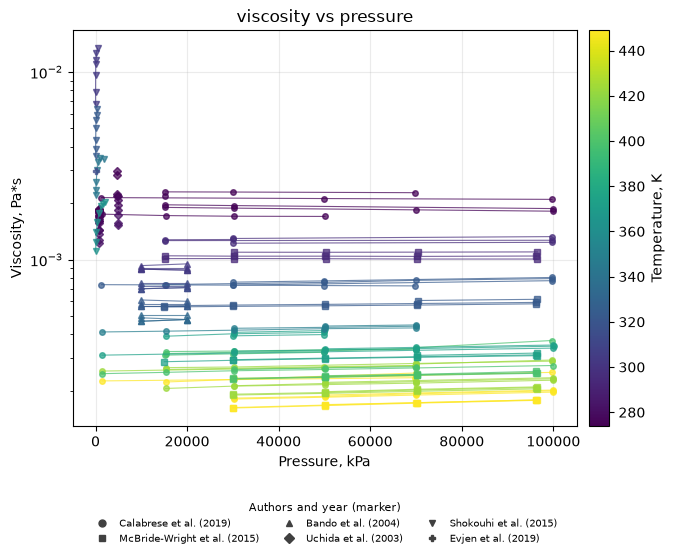

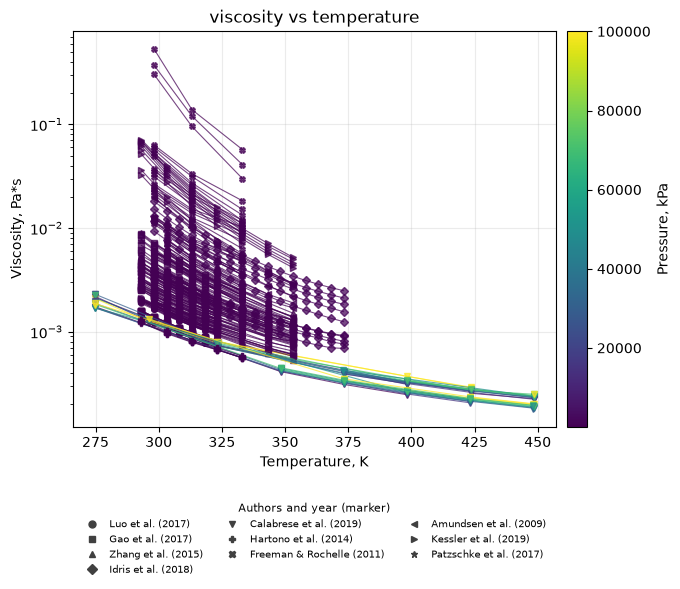

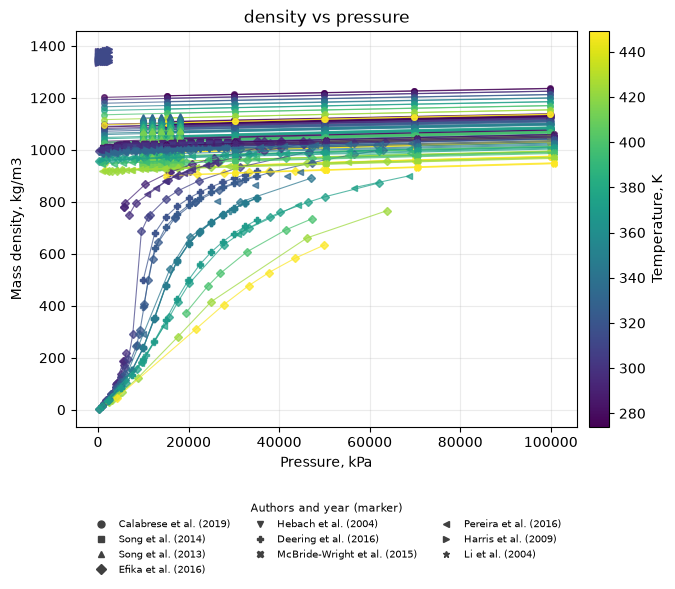

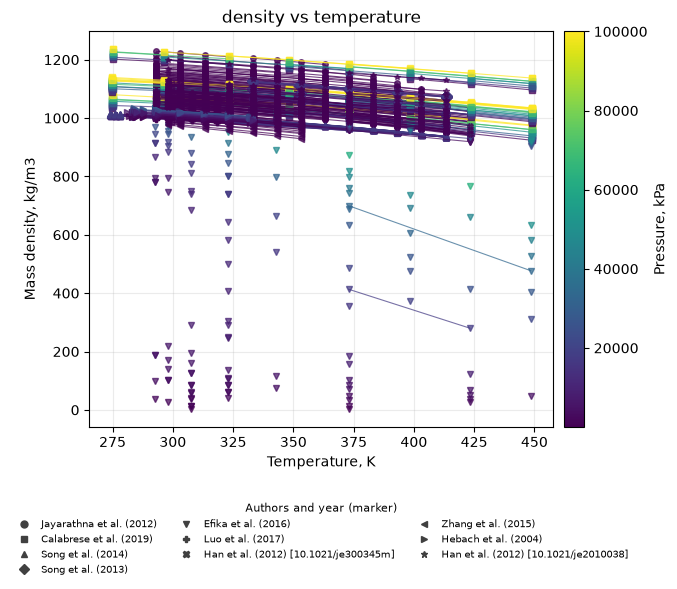

In [5]:
MARKERS = ("o", "s", "^", "D", "v", "P", "X", "<", ">", "*")


def primary_complementary_condition(
    raw_conditions: str, independent_name: str
) -> tuple[float | None, str]:
    target = (
        "pressure" if "temperature" in independent_name.casefold() else "temperature"
    )
    conditions = json.loads(raw_conditions)
    for condition in conditions:
        if target in str(condition["name"]).casefold():
            try:
                return float(condition["value"]), str(condition["name"])
            except (TypeError, ValueError):
                continue
    return None, f"Complementary {target}"


def plot_query(label: str, result) -> None:
    frame = result.table.to_pandas().copy()
    frame["x"] = pd.to_numeric(frame["independent_variable_value"])
    frame["y"] = pd.to_numeric(frame["value"])
    frame["publication_identity"] = frame["doi"].fillna(frame["source_sha256"])
    frame["publication"] = frame["citation_authors_year"]
    collisions = frame.groupby("publication")["publication_identity"].transform(
        "nunique"
    )
    frame.loc[collisions > 1, "publication"] += (
        " [" + frame.loc[collisions > 1, "publication_identity"] + "]"
    )
    complements = frame.apply(
        lambda row: primary_complementary_condition(
            row["complementary_conditions_json"],
            row["independent_variable_name"],
        ),
        axis=1,
        result_type="expand",
    )
    frame[["complementary_value", "complementary_label"]] = complements
    properties = tuple(frame["property_name"].drop_duplicates())
    figure, axes = plt.subplots(
        1,
        len(properties),
        figsize=(7 * len(properties), 6.0),
        squeeze=False,
    )
    largest_publication_count = 0
    for axis, property_name in zip(axes[0], properties, strict=True):
        selected = frame[frame["property_name"] == property_name]
        publications = tuple(selected["publication"].drop_duplicates())
        largest_publication_count = max(largest_publication_count, len(publications))
        marker_by_publication = {
            publication: MARKERS[index % len(MARKERS)]
            for index, publication in enumerate(publications)
        }
        numeric_conditions = pd.to_numeric(
            selected["complementary_value"], errors="coerce"
        )
        finite_conditions = numeric_conditions.dropna()
        lower = float(finite_conditions.min()) if not finite_conditions.empty else 0.0
        upper = float(finite_conditions.max()) if not finite_conditions.empty else 1.0
        if lower == upper:
            lower -= 0.5
            upper += 0.5
        normalization = Normalize(vmin=lower, vmax=upper)
        colormap = plt.get_cmap("viridis")
        grouped = selected.groupby(
            [
                "publication",
                "complementary_value",
                "complementary_conditions_json",
            ],
            dropna=False,
            sort=False,
        )
        for (publication, condition_value, _signature), group in grouped:
            ordered = group.sort_values("x")
            color = (
                colormap(normalization(float(condition_value)))
                if pd.notna(condition_value)
                else "0.55"
            )
            axis.plot(
                ordered["x"],
                ordered["y"],
                color=color,
                marker=marker_by_publication[publication],
                linewidth=0.8 if len(ordered) > 1 else 0,
                markersize=4,
                alpha=0.72,
            )
        axis.set_xlabel(str(selected["independent_variable_name"].iloc[0]))
        axis.set_ylabel(str(property_name))
        if "viscosity" in str(property_name).casefold():
            axis.set_yscale("log")
        axis.set_title(label.replace("_", " "))
        axis.grid(alpha=0.25)
        publication_handles = [
            Line2D(
                [],
                [],
                color="0.25",
                marker=marker_by_publication[publication],
                linestyle="None",
                markersize=5,
                label=publication,
            )
            for publication in publications
        ]
        axis.legend(
            handles=publication_handles,
            title="Authors and year (marker)",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.17),
            ncol=min(3, len(publications)),
            fontsize=7,
            title_fontsize=8,
            frameon=False,
        )
        colorbar = figure.colorbar(
            ScalarMappable(norm=normalization, cmap=colormap),
            ax=axis,
            pad=0.02,
        )
        colorbar.set_label(str(selected["complementary_label"].iloc[0]))
    figure.tight_layout()
    figure.subplots_adjust(bottom=0.28 if largest_publication_count > 3 else 0.20)
    plt.show()


for query_label, query_result in results.items():
    plot_query(query_label, query_result)

## One analysis-ready CSV per query

Each CSV has one row per property observation. Temperature, pressure,
composition, and the selected property are ordinary physical columns;
DOI, authors/year, system, method, and dataset identity follow them. The
compact `metadata` column retains uncertainties, citations, samples, devices,
and source provenance. Files remain under the ignored local-only boundary.

In [6]:
csv_manifest = pd.DataFrame(
    [
        {
            "query": label,
            "CSV": str(
                result.write_csv(LOCAL_EXPORT / "co2-h2o" / f"{label}.csv").relative_to(
                    PROJECT_ROOT
                )
            ),
            "rows": len(result.analysis_table.rows),
            "columns": len(result.analysis_table.columns),
        }
        for label, result in results.items()
    ]
)
display(csv_manifest)

,query,CSV,rows,columns
0,viscosity_vs_pressure,notebooks/local-only/exports/co2-h2o/viscosity...,299,19
1,viscosity_vs_temperature,notebooks/local-only/exports/co2-h2o/viscosity...,1409,20
2,density_vs_pressure,notebooks/local-only/exports/co2-h2o/density_v...,2314,21
3,density_vs_temperature,notebooks/local-only/exports/co2-h2o/density_v...,3704,24


In [7]:
preview_label = next(label for label, result in results.items() if result.table.rows)
print(f"Analysis-ready columns for {preview_label!r}:")
display(results[preview_label].analysis_table.to_pandas().head())

Analysis-ready columns for 'viscosity_vs_pressure':


,"Temperature, K","Pressure, kPa","Molality, mol/kg [constraint; phase=Liquid; component=calcium chloride]","Molality, mol/kg [constraint; phase=Liquid; component=sodium chloride]","Molality, mol/kg [variable; phase=Liquid; component=carbon dioxide]",Mole fraction,Solvent: Mass fraction,Amount ratio of solute to solvent,Mass ratio of solute to solvent,"Viscosity, Pa*s",DOI,Authors/Year,System,System Type,Phases,Method,Data Category,Dataset,metadata
0,274.75,1300,1,NaN,0,NaN,NaN,NaN,NaN,0.002142,10.1021/acs.jced.9b00248,Calabrese et al. (2019),carbon dioxide + calcium chloride + water,ternary,Liquid,Vibrating wire viscometry,transport,10.1021/acs.jced.9b00248#pure-or-mixture-2,"{""conditions"":[{""component"":null,""definition_r..."
1,274.75,49900,1,NaN,0,NaN,NaN,NaN,NaN,0.002117,10.1021/acs.jced.9b00248,Calabrese et al. (2019),carbon dioxide + calcium chloride + water,ternary,Liquid,Vibrating wire viscometry,transport,10.1021/acs.jced.9b00248#pure-or-mixture-2,"{""conditions"":[{""component"":null,""definition_r..."
2,274.75,99700,1,NaN,0,NaN,NaN,NaN,NaN,0.002096,10.1021/acs.jced.9b00248,Calabrese et al. (2019),carbon dioxide + calcium chloride + water,ternary,Liquid,Vibrating wire viscometry,transport,10.1021/acs.jced.9b00248#pure-or-mixture-2,"{""conditions"":[{""component"":null,""definition_r..."
3,296.21,30100,1,NaN,0,NaN,NaN,NaN,NaN,0.001224,10.1021/acs.jced.9b00248,Calabrese et al. (2019),carbon dioxide + calcium chloride + water,ternary,Liquid,Vibrating wire viscometry,transport,10.1021/acs.jced.9b00248#pure-or-mixture-2,"{""conditions"":[{""component"":null,""definition_r..."
4,296.21,99700,1,NaN,0,NaN,NaN,NaN,NaN,0.001237,10.1021/acs.jced.9b00248,Calabrese et al. (2019),carbon dioxide + calcium chloride + water,ternary,Liquid,Vibrating wire viscometry,transport,10.1021/acs.jced.9b00248#pure-or-mixture-2,"{""conditions"":[{""component"":null,""definition_r..."


## Interpretation and limitations

- `contains` includes every higher-order system containing both required
  components; use `exact` for only binary CO₂ + H₂O.
- Fewer than ten publications are retained when fewer than ten qualify.
- Counts are property-variable pairs, not independent experiments.
- Plot color parameterizes the complementary pressure or temperature; marker
  identifies the authors-year citation. DOI remains in the table, and resolves
  a label collision if two publications share the same authors-year string.
  Connecting segments require the complete complementary-condition signature
  to be identical.
- Fixed constraints are not treated as varied axes. They are exported as
  physical columns and retain their full descriptors in `metadata.conditions`.
- The pinned snapshot covers publications through 2019; the monthly upstream
  registry workflow detects future NIST snapshots without distributing them.
- ThermoML representation is not a critical evaluation of the measurements;
  cite and inspect original publications before scientific model validation.